
[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Muster: (a|b)c*d?

--- AST (Strukturbaum) ---


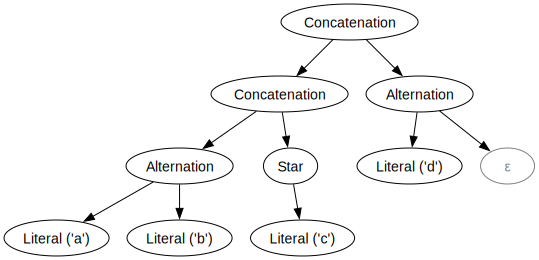


--- NFA (Automat) ---


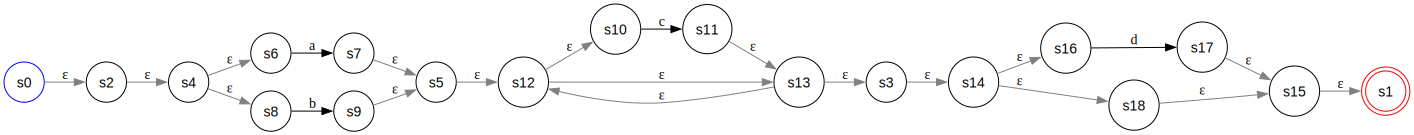

In [1]:
!pip install graphviz
import sys
import graphviz
from dataclasses import dataclass
from ast_parser import RegexParser, regex_parsen, Literal, Concatenation, Alternation, ast_to_dot, UnaryOp
from automaton import State, NFA, nfa_to_dot
from regex import regex_test, regex_find

sys.path.append('.')


def regex_visualisieren(pattern, build_func=None, parse_func=regex_parsen):
    ast = parse_func(pattern)
    print(f"Muster: {pattern}")

    print("\n--- AST (Strukturbaum) ---")
    display(graphviz.Source(ast_to_dot(ast)))

    if build_func:
        nfa = build_func(ast, [0])
        print("\n--- NFA (Automat) ---")
        display(graphviz.Source(nfa_to_dot(nfa)))
    else:
        print("\n--- NFA noch nicht erstellt (keine build_func angegeben) ---")


def neuer_zustand(counter):
    name = f"s{counter[0]}"
    counter[0] += 1
    return State(name)


def nfa_bauen(node, state_counter):
    if node is None:
        state = neuer_zustand(state_counter)
        return NFA(state, state)

    transformiert = knoten_transformieren(node, state_counter)

    if transformiert is None:
        raise TypeError(f"Diesen Knotentyp können wir noch nicht verarbeiten: {type(node)}")
    else:
        return transformiert


@dataclass
class Star(UnaryOp):
    pass


def regex_parsen(pattern):
    parser = RegexParser(pattern)
    parser.postfix_handlers['*'] = lambda node: Star(node)
    parser.postfix_handlers['?'] = lambda node: Alternation(node, None)
    return parser.parse()


def literal_transformieren(node, state_counter=None):
    start = neuer_zustand(state_counter)
    accept = neuer_zustand(state_counter)
    start.add_transition(node.char, accept)
    return NFA(start, accept)


def star_transformieren(node, state_counter):
    inner = nfa_bauen(node.expression, state_counter)
    start = neuer_zustand(state_counter)
    accept = neuer_zustand(state_counter)
    start.add_transition(None, inner.start_state)
    start.add_transition(None, accept)
    accept.add_transition(None, start)
    inner.accept_state.add_transition(None, accept)
    return NFA(start, accept)


def concatenation_transformieren(node, state_counter):
    start = neuer_zustand(state_counter)
    accept = neuer_zustand(state_counter)
    links = nfa_bauen(node.left, state_counter)
    rechts = nfa_bauen(node.right, state_counter)
    links.accept_state.add_transition(None, rechts.start_state)
    start.add_transition(None, links.start_state)
    rechts.accept_state.add_transition(None, accept)
    return NFA(start, accept)


def alternation_transformieren(node, state_counter):
    start = neuer_zustand(state_counter)
    accept = neuer_zustand(state_counter)
    links = nfa_bauen(node.left, state_counter)
    rechts = nfa_bauen(node.right, state_counter)
    start.add_transition(None, links.start_state)
    start.add_transition(None, rechts.start_state)
    links.accept_state.add_transition(None, accept)
    rechts.accept_state.add_transition(None, accept)
    return NFA(start, accept)


def star_transformieren(node, state_counter):
    inner = nfa_bauen(node.expression, state_counter)
    start = neuer_zustand(state_counter)
    accept = neuer_zustand(state_counter)
    start.add_transition(None, inner.start_state)
    start.add_transition(None, accept)
    accept.add_transition(None, start)
    inner.accept_state.add_transition(None, accept)
    return NFA(start, accept)


def knoten_transformieren(node, state_counter):
    if isinstance(node, Literal):
        return literal_transformieren(node, state_counter)
    elif isinstance(node, Concatenation):
        return concatenation_transformieren(node, state_counter)
    elif isinstance(node, Alternation):
        return alternation_transformieren(node, state_counter)
    elif isinstance(node, Star):
        return star_transformieren(node, state_counter)
    return None


# Teste dein Ergebnis:
regex_visualisieren("(a|b)c*d?", parse_func=regex_parsen, build_func=nfa_bauen)

Fehlt nur noch die Implementierung in unserer Transformation:

### Herausforderung: Zeichengruppen `[a-z]`

Wir bilden Zeichengruppen wie `[a-c]` als eigenständigen Knoten im AST ab. Im Grunde handelt es sich aber dabei um eine Alternation `(a|b|c)`.

**Bauprinzip**: Eine Gruppe `[a-c]` funktioniert wie eine Alternation (`a|b|c`). Du musst also für jedes Zeichen in der Gruppe einen Übergang vom Start- zum Endzustand erstellen.

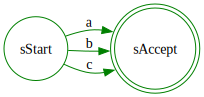

In [2]:
## TODO: DOUBLE ALTERNATION

display(graphviz.Source(
    'digraph { rankdir=LR; node [shape=circle]; sStart [label="sStart", color=green]; sAccept [label="sAccept", shape=doublecircle, color=green]; sStart -> sAccept [label="a", color=green]; sStart -> sAccept [label="b", color=green]; sStart -> sAccept [label="c", color=green]; }'))

In [3]:
from ast_parser.ast_nodes import CharacterGroup


# Eine Funktion zum Parsen der […] Zeichengruppe-Deklaration
def handle_char_group(p):
    if p.peek() == '[':
        p.consume()  # '['
        chars = []
        while p.peek() and p.peek() != ']':
            char = p.consume()
            if p.peek() == '-' and p.pos + 1 < len(p.pattern) and p.pattern[p.pos + 1] != ']':
                p.consume()  # '-'
                end_char = p.consume()
                for c in range(ord(char), ord(end_char) + 1):
                    chars.append(chr(c))
            else:
                chars.append(char)
        if p.consume() != ']':
            raise ValueError("Erwartetes ']' fehlt")
        return CharacterGroup(chars)
    return None


def regex_parsen(pattern):
    parser = RegexParser(pattern)
    parser.postfix_handlers['*'] = lambda node: Star(node)
    parser.postfix_handlers['?'] = lambda node: Alternation(node, None)
    # Wir erweitern den Parser um die Unterstützung von CharacterGroup
    parser.atom_handlers.insert(0, handle_char_group)
    return parser.parse()


def chargroup_transformieren(node, state_counter):
    # TODO: Implementiere die Konstruktion für CharacterGroup
    # In node.chars findest du eine Liste aller erlaubten Zeichen dieser Zeichengruppe
    start = neuer_zustand(state_counter)
    accept = neuer_zustand(state_counter)
    for char in node.chars:
        start.add_transition(char, accept)
    return NFA(start, accept)


def knoten_transformieren(node, state_counter):
    if isinstance(node, Literal):
        return literal_transformieren(node, state_counter)
    elif isinstance(node, Concatenation):
        return concatenation_transformieren(node, state_counter)
    elif isinstance(node, Alternation):
        return alternation_transformieren(node, state_counter)
    elif isinstance(node, Star):
        return star_transformieren(node, state_counter)
    elif isinstance(node, CharacterGroup):
        return chargroup_transformieren(node, state_counter)
    return None

### Die Zeichengruppen testen

Probier es aus mit `[a-c]d`!

Muster: [a-c]d

--- AST (Strukturbaum) ---


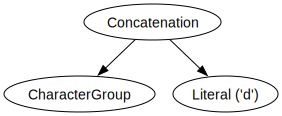


--- NFA (Automat) ---


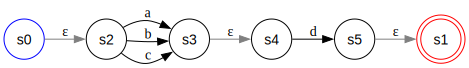

In [4]:
regex_visualisieren("[a-c]d", build_func=nfa_bauen, parse_func=regex_parsen)

### Herausforderung für Profis

Wenn du noch Zeit hast, versuche folgende Dinge einzubauen:
- `+` (Eins oder mehr): Ähnlich wie `?` und `*`.
- `{n,m}` (Wiederholung): Hier musst du einen komplexeren Handler schreiben, der die Zahlen im String ausliest.
- Negierte Gruppen `[^a-z]`: Alles außer den angegebenen Zeichen.

In [5]:
# TODO Spielwiese

## Praxis-Anwendung: Beispiele

Jetzt, wo wir die Grundlagen der Thompson-Konstruktion beherrschen, wenden wir sie auf reale Daten an!

Wir nutzen `regex_find`, um Daten aus den Beispieldateien zu filtern.

In [6]:
# Beispiel 1: Log-Analyse - Suche nach "INFO"-Meldungen
print("--- Log-Analyse (Suche nach \"INFO\") ---")
with open("../data/logs.txt", "r") as f:
    for line in f:
        if regex_find("INFO", line.strip(), parse_func=regex_parsen, build_func=nfa_bauen):
            print(f"INFO gefunden in: {line.strip()}")

# Beispiel 2: E-Mail-Validierung - Suche nach E-Mails ohne "@"
print("\n--- E-Mail-Validierung (Suche nach \"@\") ---")
with open("../data/users.csv", "r") as f:
    next(f)  # Header überspringen
    for line in f:
        username, email = line.strip().split(",")
        # Suche nach "@" - wenn nicht gefunden, ist die E-Mail wahrscheinlich ungültig
        if not regex_find("@", email, parse_func=regex_parsen, build_func=nfa_bauen):
            print(f"Ungültige E-Mail: {email} (Benutzer: {username})")

# Beispiel 3: Daten-Extraktion - Suche nach "user1"
print("\n--- Daten-Extraktion (Suche nach \"user(1|2)\") ---")
with open("../data/logs.txt", "r") as f:
    for line in f:
        if regex_find("user(1|2)", line.strip(), parse_func=regex_parsen, build_func=nfa_bauen):
            print(f"User1 oder User2 erwähnt in: {line.strip()}")

--- Log-Analyse (Suche nach "INFO") ---
INFO gefunden in: 2026-06-20 10:00:00 INFO User logged in: user1
INFO gefunden in: 2026-06-20 10:02:00 INFO User logged out: user1
INFO gefunden in: 2026-06-20 10:03:00 INFO User logged in: user2
INFO gefunden in: 2026-06-20 10:06:00 INFO User logged out: user2

--- E-Mail-Validierung (Suche nach "@") ---
Ungültige E-Mail: invalid-email (Benutzer: user2)
Ungültige E-Mail: missing-at-sign (Benutzer: user6)

--- Daten-Extraktion (Suche nach "user(1|2)") ---
User1 oder User2 erwähnt in: 2026-06-20 10:00:00 INFO User logged in: user1
User1 oder User2 erwähnt in: 2026-06-20 10:02:00 INFO User logged out: user1
User1 oder User2 erwähnt in: 2026-06-20 10:03:00 INFO User logged in: user2
User1 oder User2 erwähnt in: 2026-06-20 10:06:00 INFO User logged out: user2
